# ABFM Skills Assessment - R Notebook
## Quick-Deploy for Synthetic EHR Analysis

# ================================================================
# SECTION 0 — PACKAGES
# ================================================================

In [1]:
# ╔════════════════════════════════════════════════════════════════╗
# ║  0A. INSTALL ANY MISSING PACKAGES (run once)                   ║
# ╚════════════════════════════════════════════════════════════════╝

required <- c(
  # ── Core data wrangling ──
  "tidyverse",   # dplyr, ggplot2, tidyr, readr, stringr, forcats, purrr, lubridate
  "data.table",  # fast CSV reads + large-data joins

  # ── EDA & data quality ──
  "naniar",      # missing data visualisation (gg_miss_var, vis_miss)
  "visdat",      # vis_dat() whole-dataset type overview
  "tableone",    # Table 1 demographics summary with p-values
  "DescTools",   # misc descriptive utilities
  "corrplot",    # correlation matrix heatmap
  "ggcorrplot",  # ggplot2-style correlation heatmap
  "UpSetR",      # upset plots for set intersections (comorbidity overlap)
  "cowplot",     # multi-panel ggplot layouts
  "gridExtra",   # grid.arrange for side-by-side plots
  "ggpubr",      # publication-ready ggplot themes + stat_compare_means
  "ggrepel",     # non-overlapping text labels in ggplot
  "scales",      # percent(), comma() for axis formatting
  "viridis",     # colourblind-friendly palettes
  "car",         # vif() for multicollinearity check

  # ── General linear / generalised linear models ──
  "MASS",        # glm.nb() negative binomial; stepAIC
  "glmnet",      # LASSO / elastic net regularised GLM
  "mgcv",        # gam() generalised additive models
  "statmod",     # tweedie() distribution family for GLM cost models
  "pscl",        # zeroinfl() zero-inflated Poisson / NB
  "sandwich",    # HC robust standard errors

  # ── Mixed-effects / multilevel models ──
  "lme4",        # lmer(), glmer() — the workhorse for nested/clustered data
  "lmerTest",    # adds p-values to lmer via Satterthwaite
  "performance", # icc(), model_performance(), check_model()
  "broom.mixed", # tidy() for lme4 objects
  "broom",       # tidy(), glance(), augment() for all model families

  # ── Bayesian methods ──
  "brms",        # Bayesian mixed models (Stan backend)
  "rstanarm",    # stan_glmer() — simpler Bayesian mixed models
  "bayestestR",  # describe_posterior(), rope(), equivalence tests
  "bayesplot",   # mcmc_trace, mcmc_areas for MCMC diagnostics

  # ── Survival / time-to-event ──
  "survival",    # Surv(), survfit(), coxph(), survreg()
  "survminer",   # ggsurvplot() — KM curves with risk tables
  "flexsurv",    # flexible parametric survival (Weibull, Gompertz, spline)

  # ── Machine learning: tree methods ──
  "randomForest", # classic RF
  "ranger",       # fast RF (preferred for large n)
  "xgboost",      # gradient boosted trees
  "lightgbm",     # Microsoft's gradient boosting (fast + handles categoricals)
  "gbm",          # Friedman's GBM
  "rpart",        # single decision tree
  "rpart.plot",   # pretty tree visualisation
  "C50",          # C5.0 decision tree + boosted ensemble

  # ── Machine learning: framework / tuning ──
  "caret",        # unified ML training framework (train(), confusionMatrix())
  "yardstick",    # metric functions (roc_auc, rmse, etc.)
  "pROC",         # ROC curves + AUC with CI
  "Metrics",      # rmse(), mae(), auc(), logloss()
  "vip",          # variable importance plots (model-agnostic)
  "recipes",      # tidymodels preprocessing pipelines

  # ── Propensity scores / causal inference ──
  "MatchIt",      # propensity score matching (nearest, optimal, CEM)

  # ── Time series ──
  "zoo",          # zoo time series objects, rollmean()
  "xts",          # extensible time series

  # ── Misc ──
  "e1071",        # SVM + skewness/kurtosis functions
  "rstatix"       # pipe-friendly stats (t_test, anova_test, etc.)
)

# Only install what's missing
missing <- required[!(required %in% installed.packages()[,"Package"])]
if (length(missing) > 0) {
  cat("Installing:", paste(missing, collapse=", "), "\n")
  install.packages(missing, repos="https://cloud.r-project.org", quiet=TRUE)
} else {
  cat("All", length(required), "packages already installed. Good to go.\n")
}

All 53 packages already installed. Good to go.


In [2]:
# ╔════════════════════════════════════════════════════════════════╗
# ║  0B. LOAD LIBRARIES                                            ║
# ╚════════════════════════════════════════════════════════════════╝

suppressPackageStartupMessages({

  # ── Core data wrangling ──
  library(tidyverse)    # dplyr ggplot2 tidyr readr stringr forcats purrr lubridate
  library(data.table)

  # ── EDA & data quality ──
  library(naniar)       # gg_miss_var, vis_miss
  library(visdat)       # vis_dat
  library(tableone)     # CreateTableOne
  library(DescTools)    # Desc, MeanCI, etc.
  library(corrplot)     # corrplot()
  library(ggcorrplot)   # ggcorrplot()
  library(UpSetR)       # upset()
  library(cowplot)      # plot_grid()
  library(gridExtra)    # grid.arrange()
  library(ggpubr)       # ggarrange, stat_compare_means
  library(ggrepel)      # geom_text_repel
  library(scales)       # percent, comma
  library(viridis)      # scale_fill_viridis
  library(car)          # vif()

  # ── GLM / regression ──
  library(MASS)         # glm.nb, stepAIC
  library(glmnet)       # cv.glmnet
  library(mgcv)         # gam, s()
  library(statmod)      # tweedie family
  library(pscl)         # zeroinfl
  library(sandwich)     # vcovHC

  # ── Mixed-effects ──
  library(lme4)         # glmer
  library(lmerTest)     # p-values for lmer
  library(performance)  # icc(), r2()
  library(broom)        # tidy
  library(broom.mixed)  # tidy for lme4

  # ── Bayesian ──
  # library(brms)       # uncomment if needed — slow to load
  # library(rstanarm)   # uncomment if needed — slow to load
  library(bayestestR)   # describe_posterior

  # ── Survival ──
  library(survival)     # Surv, survfit, coxph, survreg
  library(survminer)    # ggsurvplot
  library(flexsurv)     # flexsurvreg

  # ── ML tree methods ──
  library(randomForest)
  library(ranger)
  library(xgboost)
  library(gbm)
  library(rpart)
  library(rpart.plot)

  # ── ML framework / metrics ──
  library(caret)        # train, confusionMatrix, createDataPartition
  library(pROC)         # roc, auc, ci.auc
  library(Metrics)      # rmse, mae
  library(vip)          # vip() variable importance

  # ── Propensity matching ──
  library(MatchIt)

  # ── Time series ──
  library(zoo)

  # ── Misc ──
  library(e1071)        # skewness, kurtosis, SVM
  library(rstatix)      # pipe-friendly stats
})

cat("All libraries loaded.\n")

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'lubridate' was built under R version 4.4.3"
Warning message:
"package 'ggpubr' was built under R version 4.4.3"
Warning message:
"package 'ggrepel' was built under R version 4.4.3"
Warning message:
"package 'lme4' was built under R version 4.4.3"
Warning message:
"package 'lmerTest' was built under R version 4.4.3"
Warning message:
"package 'performance' was built under R version 4.4.3"
Warning message:
"package 'broom' was built under R version 4.4.3"
Warning message:
"package 'broom.mixed' was built under R version 4.4.3"
Warning message:
"package 'survival' was built under R version 4.4.3"
Warning message:
"package 'survminer' was built under R version 4.4.3"


All libraries loaded.


# ================================================================
# SECTION 1 — DATA LOADING
# ================================================================

In [4]:
# ╔════════════════════════════════════════════════════════════════╗
# ║  1A. LOAD ALL 8 TABLES                                         ║
# ╚════════════════════════════════════════════════════════════════╝

DATA_PATH <- "data/"

# Auto-detect all CSV files in the folder
csv_files <- list.files(DATA_PATH, pattern = "\\.csv$", full.names = TRUE)
cat("Found", length(csv_files), "CSV files:\n")
cat(paste(" ", basename(csv_files)), sep = "\n")

# Read each into a named list AND assign to individual variables
all_tables <- list()
all_tables_original <- list()
for (f in csv_files) {
  nm <- tools::file_path_sans_ext(basename(f))
  df <- read_csv(f, show_col_types = FALSE)
  all_tables[[nm]] <- df
  all_tables_original[[nm]] <- df
  assign(nm, df, envir = .GlobalEnv)
  assign(paste0(nm,"_original"), df, envir = .GlobalEnv)
  cat(sprintf("  %-25s: %6s rows  x  %2d cols\n",
              nm, format(nrow(df), big.mark=","), ncol(df)))
}

cat("\nAll tables loaded into global env by their file name.\n")
cat("\nOriginal tables loaded by their file name _original.\n")
cat("Also accessible via all_tables[['table_name']].\n")

Found 9 CSV files:
  US_zip_elevation.csv
  allergies.csv
  conditions.csv
  encounters.csv
  medications.csv
  observations.csv
  patients.csv
  payer_transitions.csv
  payers.csv
  US_zip_elevation         : 41,483 rows  x   2 cols
  allergies                : 21,045 rows  x  15 cols
  conditions               : 1,032,326 rows  x   7 cols
  encounters               : 1,809,356 rows  x  15 cols
  medications              : 1,460,996 rows  x  13 cols
  observations             : 9,020,852 rows  x   9 cols
  patients                 : 10,000 rows  x  28 cols
  payer_transitions        : 1,168,680 rows  x   8 cols
  payers                   :     40 rows  x  22 cols

All tables loaded into global env by their file name.

Original tables loaded by their file name _original.
Also accessible via all_tables[['table_name']].


# ================================================================
# SECTION 2 — EXPLORATORY DATA ANALYSIS
# ================================================================

In [5]:
# ╔════════════════════════════════════════════════════════════════╗
# ║  2A. DATA TYPES/STRUCTURE AND MISSINGNESS — per table          ║
# ╚════════════════════════════════════════════════════════════════╝

for (nm in names(all_tables)) {
  df <- all_tables[[nm]]
  cat("\n", strrep("=", 60), "\n")
  cat(" ", nm, "(", nrow(df), "rows x", ncol(df), "cols)\n")
  cat(strrep("=", 60), "\n")

  # Column types
  type_summary <- tibble(
    column     = names(df),
    type       = map_chr(df, ~ class(.x)[1]),
    n_unique   = map_int(df, n_distinct),
    n_missing  = map_int(df, ~ sum(is.na(.x))),
    pct_miss   = round(100 * n_missing / nrow(df), 1),
    sample_val = map_chr(df, ~ as.character(.x[!is.na(.x)][1]))
  )
  print(type_summary, n = 30)
}


  US_zip_elevation ( 41483 rows x 2 cols)
# A tibble: 2 x 6
  column                  type    n_unique n_missing pct_miss sample_val 
  <chr>                   <chr>      <int>     <int>    <dbl> <chr>      
1 postalcode              numeric    41481         0      0   99553      
2 SRTM_zip_elevation_mean numeric    30611       190      0.5 47.93571429

  allergies ( 21045 rows x 15 cols)
# A tibble: 15 x 6
   column       type      n_unique n_missing pct_miss sample_val                
   <chr>        <chr>        <int>     <int>    <dbl> <chr>                     
 1 START        Date          3842         0      0   1991-01-13                
 2 STOP         logical          1     21045    100   NA                        
 3 PATIENT      character     3017         0      0   df36603e-6b9c-8dcf-c8be-5~
 4 ENCOUNTER    character     4145         0      0   df36603e-6b9c-8dcf-a058-0~
 5 CODE         numeric         22         0      0   84489001                  
 6 SYSTEM       char

DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2023-06-24 11:35:51,e160fa7d-50a1-5f64-db39-0f557d785f12,e160fa7d-50a1-5f64-5e71-e69a31b77ee5,social-history,82810-3,Pregnancy status,Pregnant,NA,text
2020-01-23 12:18:58,4b9bd3df-09db-4216-668d-490aaeaad415,4b9bd3df-09db-4216-e498-8807c9277f3e,social-history,72166-2,Tobacco smoking status,Never smoked tobacco (finding),NA,text
2019-03-01 14:45:30,494e3dca-4066-749a-56da-e9280657a7d9,494e3dca-4066-749a-4e68-a93b42e0b9ed,social-history,72166-2,Tobacco smoking status,Never smoked tobacco (finding),NA,text
1919-05-13 21:01:19,9eb83138-f7f6-a2b1-075e-8e0d21c8effc,9eb83138-f7f6-a2b1-4731-6381a7607795,social-history,72166-2,Tobacco smoking status,Never smoked tobacco (finding),NA,text
2012-10-02 21:23:57,480abb26-1fb2-2174-d942-c05e80499443,480abb26-1fb2-2174-4845-fc2f3033991d,survey,59461-4,Fall risk level [Morse Fall Scale],Low Risk (MFS Score 0 - 24),NA,text
2020-02-07 10:53:32,2273136e-36bf-bd64-1ce0-be7fa1dc9dc6,2273136e-36bf-bd64-1c0d-17228cbb16eb,social-history,72166-2,Tobacco smoking status,Never smoked tobacco (finding),NA,text
2020-10-10 08:29:46,dfbfc4ed-d865-c422-5153-c2cb172cff4a,dfbfc4ed-d865-c422-1164-554a58a80c59,survey,54899-0,Preferred language,English,NA,text
2013-05-31 22:50:07,fd5b4a78-bd26-7863-1d0a-a986cd51e726,fd5b4a78-bd26-7863-f806-149fc0a3e4cf,survey,59461-4,Fall risk level [Morse Fall Scale],High Risk (MFS Score 50+),NA,text
2018-06-09 05:54:26,748b579c-618c-c4bb-7f72-9e9e89c9b667,748b579c-618c-c4bb-14fb-230b99f1683c,survey,54899-0,Preferred language,English,NA,text


[1] "Florida"       "Colorado"      "Utah"          "Massachusetts"

STATE,missing_FALSE,missing_TRUE
<chr>,<int>,<int>
Colorado,2246,186
Florida,2345,554
Massachusetts,1933,658
Utah,2046,32


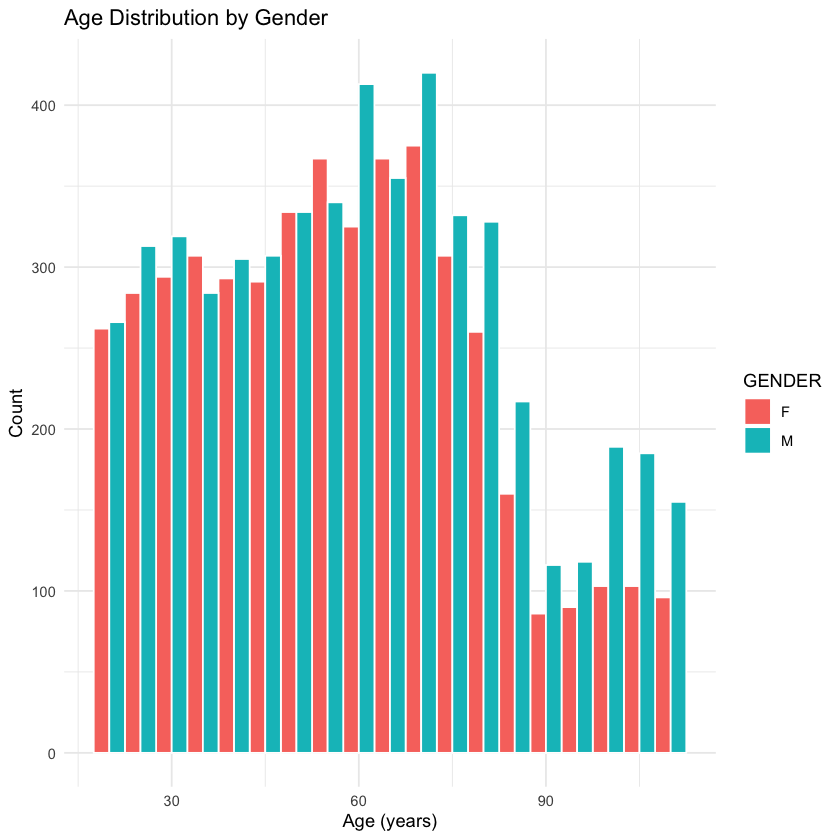

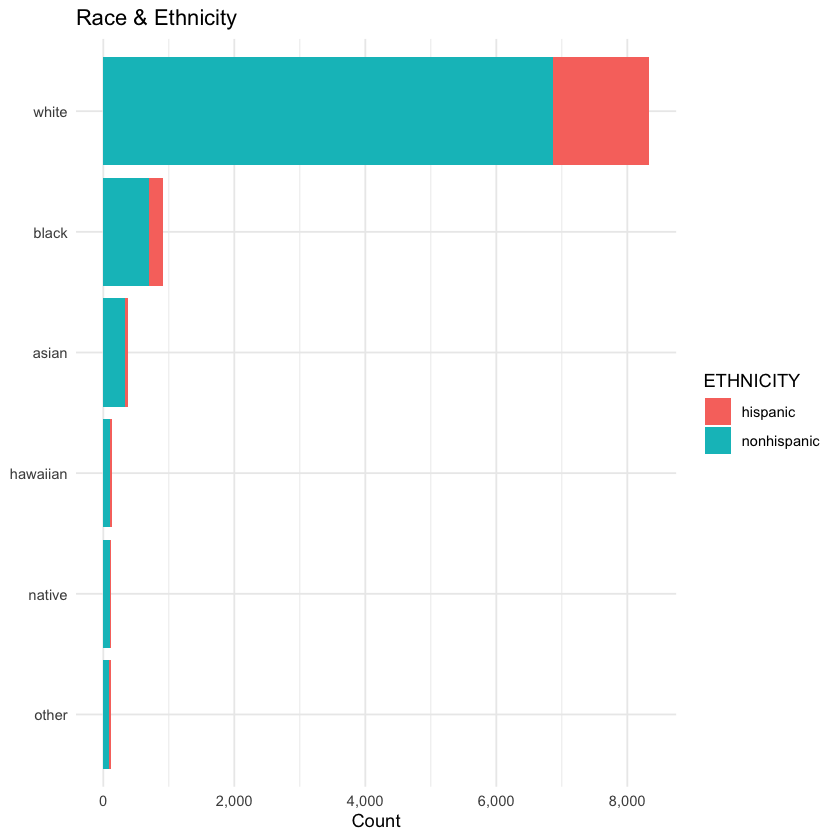

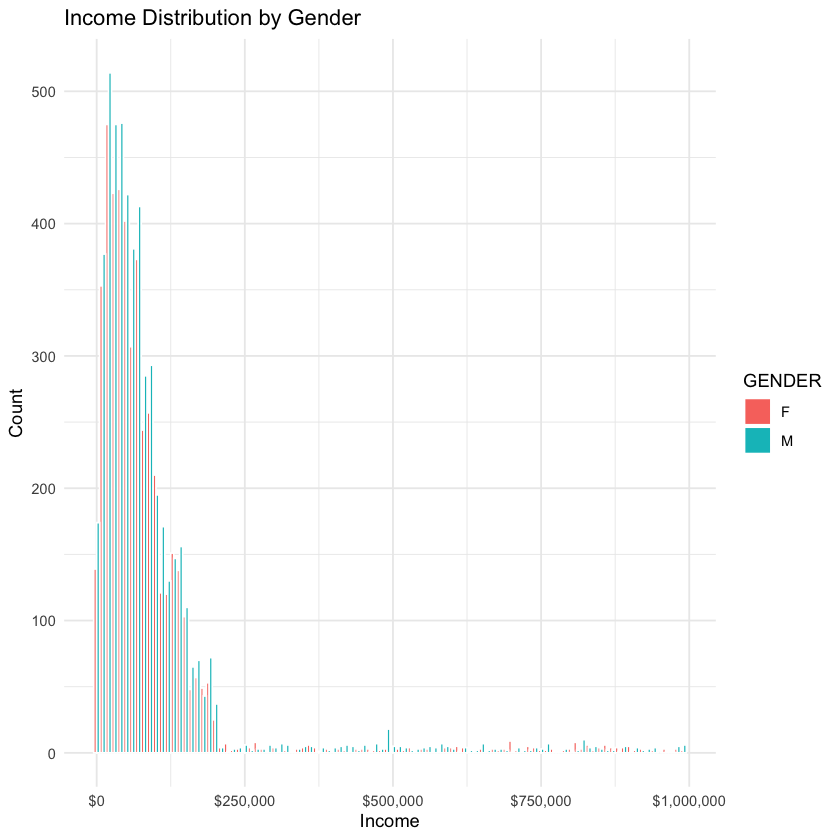

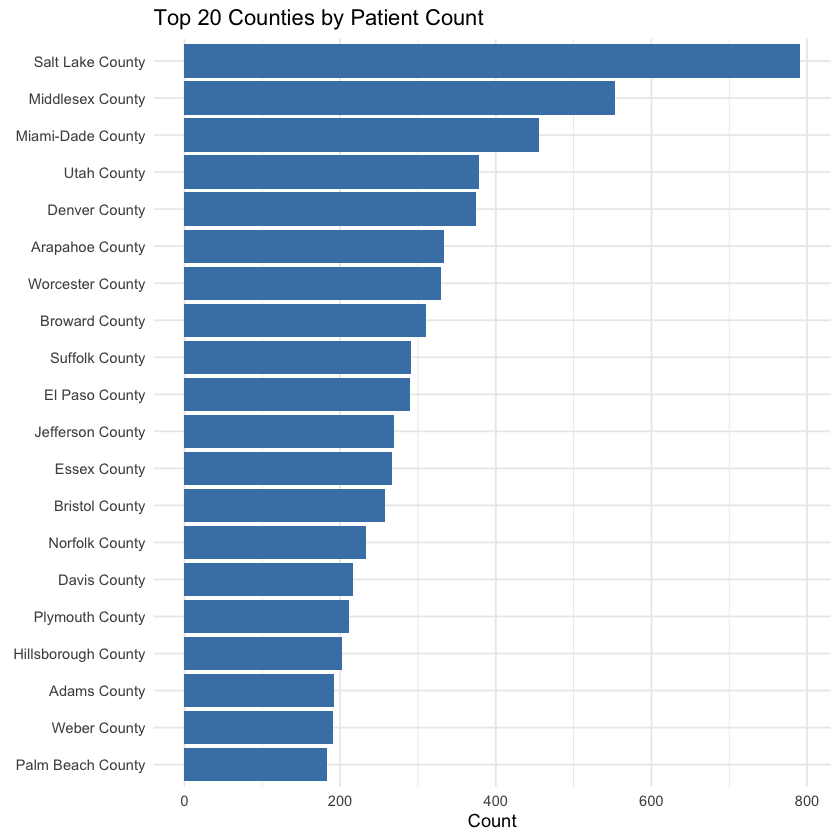

`geom_smooth()` using formula = 'y ~ x'


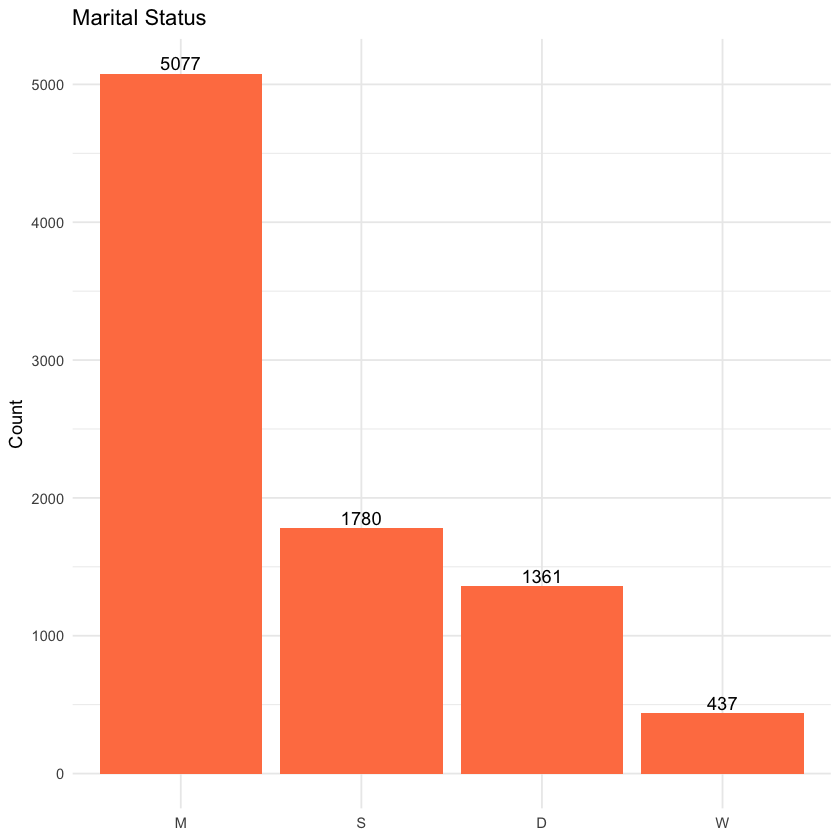

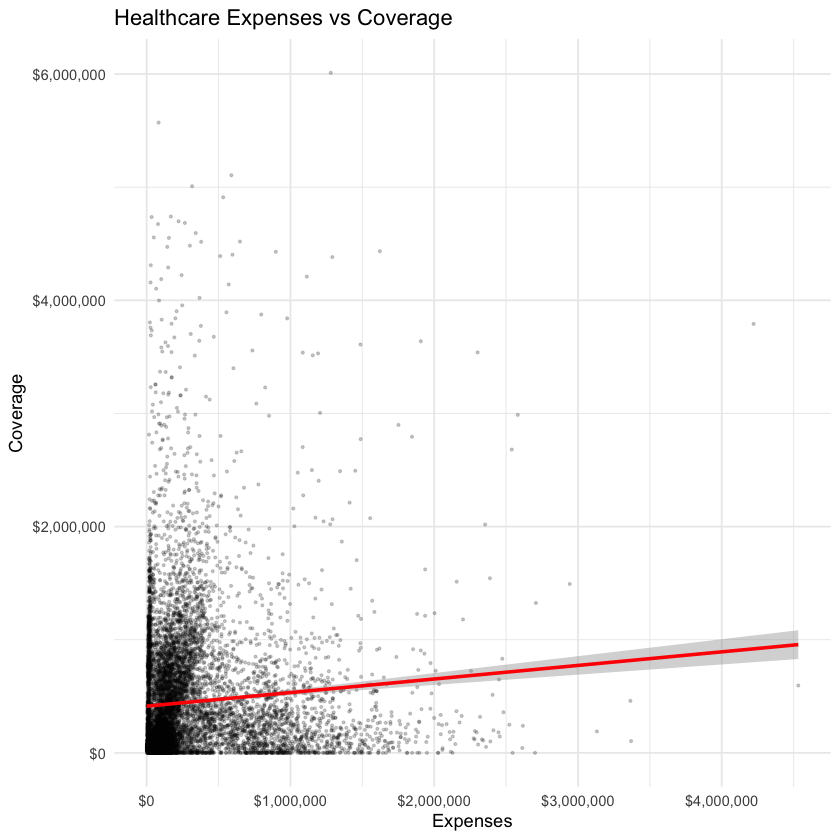

In [20]:

# all seem to be text observations = no units
observations %>%
  filter(is.na(UNITS)) %>%
  head(20)

unique(patients$STATE)

# FIPS: check if missing FIPS maps to specific ZIPs or counties
patients %>%
  mutate(FIPS_MISSING = is.na(FIPS)) %>%
  count(FIPS_MISSING, STATE) %>%
  pivot_wider(names_from = FIPS_MISSING, values_from = n, names_prefix = "missing_")

# 1. Age by gender
patients %>%
  mutate(AGE = as.numeric(difftime(Sys.Date(), BIRTHDATE, units = "days")) / 365.25) %>%
  ggplot(aes(x = AGE, fill = GENDER)) +
  geom_histogram(binwidth = 5, position = "dodge", color = "white") +
  labs(title = "Age Distribution by Gender", x = "Age (years)", y = "Count") +
  theme_minimal()

# 2. Race/ethnicity
patients %>%
  count(RACE, ETHNICITY) %>%
  ggplot(aes(x = n, y = reorder(RACE, n), fill = ETHNICITY)) +
  geom_col() +
  scale_x_continuous(labels = comma) +
  labs(title = "Race & Ethnicity", x = "Count", y = NULL) +
  theme_minimal()

# 3. Income distribution by gender
patients %>%
  ggplot(aes(x = INCOME, fill = GENDER)) +
  geom_histogram(binwidth = 10000, position = "dodge", color = "white") +
  scale_x_continuous(labels = dollar) +
  labs(title = "Income Distribution by Gender", x = "Income", y = "Count") +
  theme_minimal()

# 4. Geographic spread by county (top 20)
patients %>%
  count(COUNTY, sort = TRUE) %>%
  slice_head(n = 20) %>%
  ggplot(aes(x = n, y = reorder(COUNTY, n))) +
  geom_col(fill = "steelblue") +
  labs(title = "Top 20 Counties by Patient Count", x = "Count", y = NULL) +
  theme_minimal()

# 5. Marital status
patients %>%
  filter(!is.na(MARITAL)) %>%
  count(MARITAL) %>%
  ggplot(aes(x = reorder(MARITAL, -n), y = n)) +
  geom_col(fill = "coral") +
  geom_text(aes(label = n), vjust = -0.3) +
  labs(title = "Marital Status", x = NULL, y = "Count") +
  theme_minimal()

# 6. Healthcare expenses vs coverage
patients %>%
  ggplot(aes(x = HEALTHCARE_EXPENSES, y = HEALTHCARE_COVERAGE)) +
  geom_point(alpha = 0.2, size = 0.5) +
  geom_smooth(method = "lm", color = "red") +
  scale_x_continuous(labels = dollar) +
  scale_y_continuous(labels = dollar) +
  labs(title = "Healthcare Expenses vs Coverage", x = "Expenses", y = "Coverage") +
  theme_minimal()


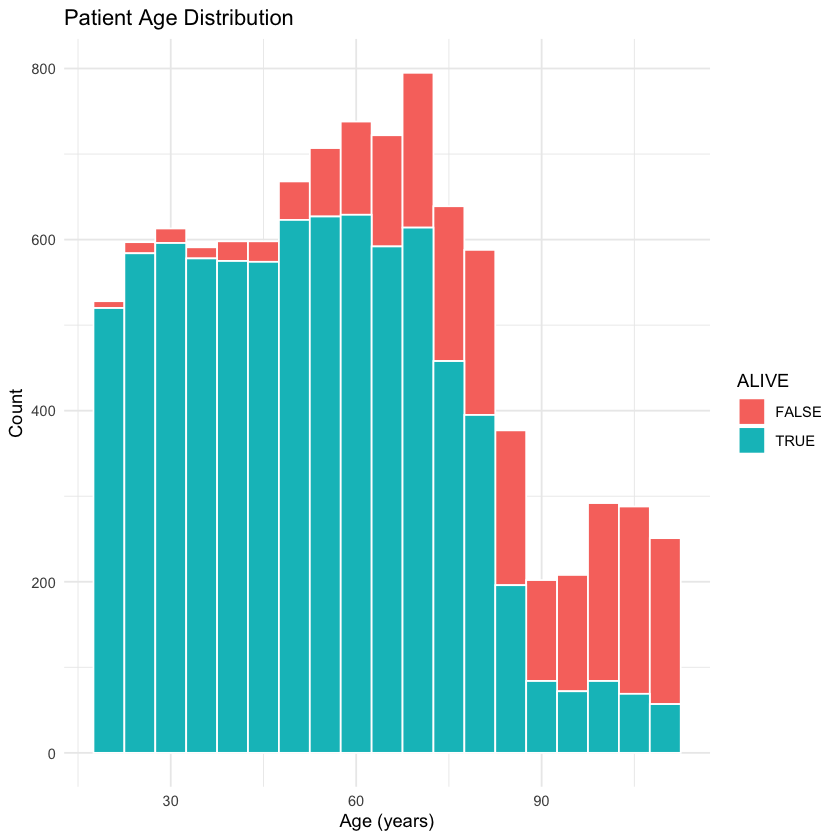

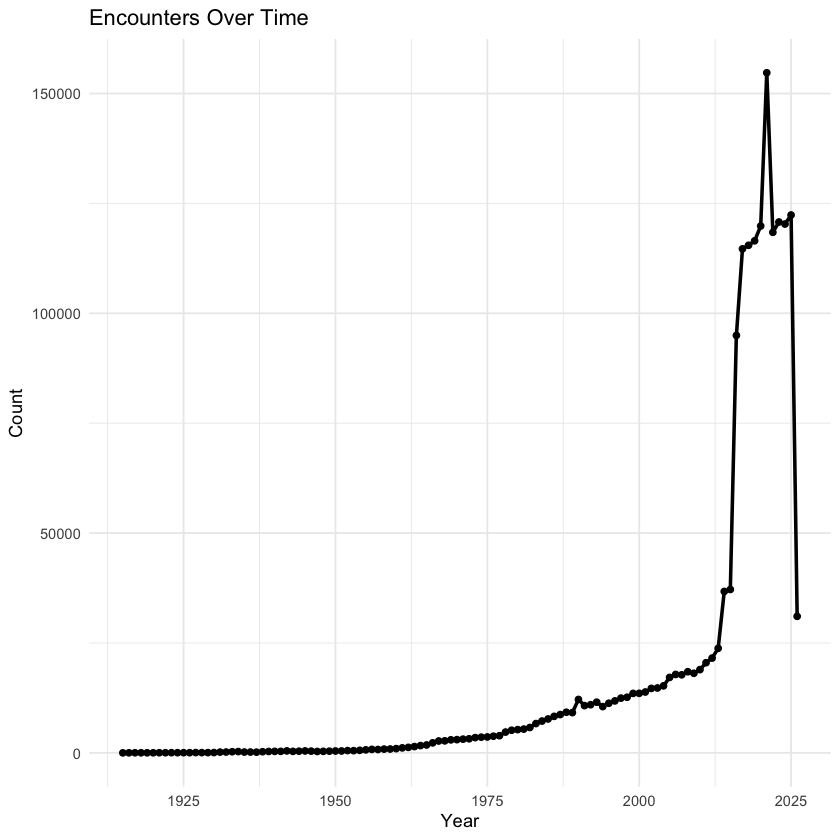

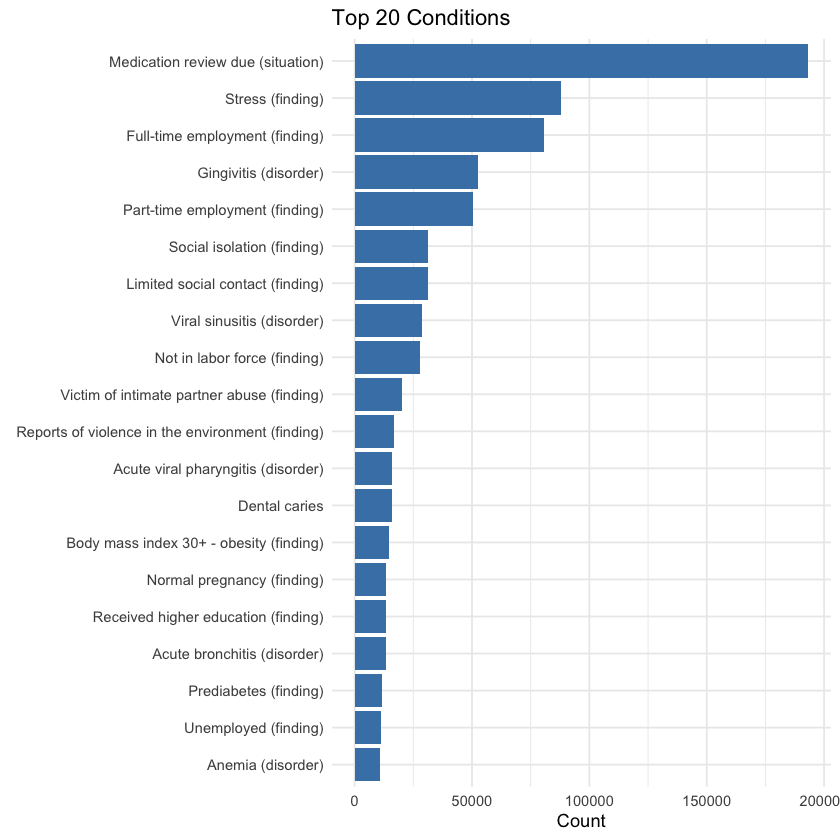

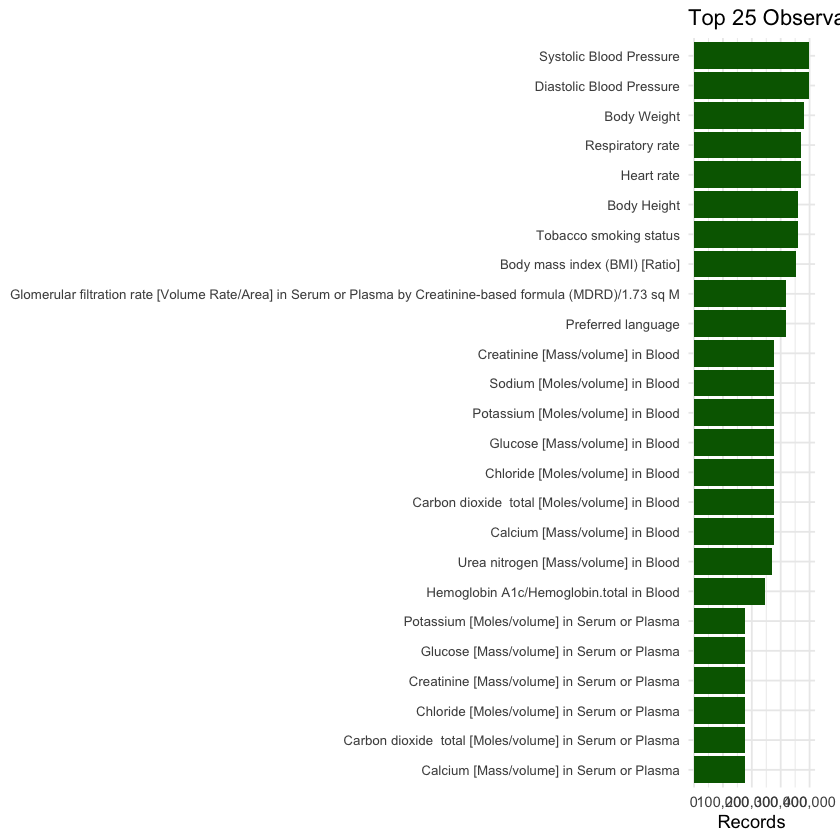

In [ ]:
# 1. Age distribution
patients <- patients %>%
  mutate(AGE = as.numeric(difftime(Sys.Date(), BIRTHDATE, units = "days")) / 365,
         ALIVE = is.na(DEATHDATE))

ggplot(patients, aes(x = AGE, fill = ALIVE)) +
  geom_histogram(binwidth = 5, color = "white") +
  labs(title = "Patient Age Distribution", x = "Age (years)", y = "Count") +
  theme_minimal()

# 2. Encounter volume by year
encounters %>%
  mutate(YEAR = year(START)) %>%
  count(YEAR) %>%
  ggplot(aes(x = YEAR, y = n)) +
  geom_line(linewidth = 1) +
  geom_point() +
  labs(title = "Encounters Over Time", x = "Year", y = "Count") +
  theme_minimal()

# 3. Top 20 conditions
conditions %>%
  count(DESCRIPTION, sort = TRUE) %>%
  slice_head(n = 20) %>%
  ggplot(aes(x = n, y = reorder(DESCRIPTION, n))) +
  geom_col(fill = "steelblue") +
  labs(title = "Top 20 Conditions", x = "Count", y = NULL) +
  theme_minimal()

# 4. Observation type completeness
observations %>%
  count(DESCRIPTION) %>%
  arrange(desc(n)) %>%
  slice_head(n = 25) %>%
  ggplot(aes(x = n, y = reorder(DESCRIPTION, n))) +
  geom_col(fill = "darkgreen") +
  scale_x_continuous(labels = comma) +
  labs(title = "Top 25 Observation Types by Frequency", x = "Records", y = NULL) +
  theme_minimal() + 
  theme(axis.text.y = element_text(size = 8),
        plot.margin = unit(c(5, 15, 5, 5), "pt"))

# ================================================================
# SECTION 3 — FEATURE ENGINEERING
# ================================================================

# ================================================================
# SECTION 4 — ANSWERS
# ================================================================

DESCRIPTION,n
<chr>,<int>
Simvastatin 10 MG Oral Tablet,29318
Simvastatin 20 MG Oral Tablet,4272
atorvastatin 40 MG Oral Tablet,214
atorvastatin 20 MG Oral Tablet,172
atorvastatin 10 MG Oral Tablet,146
simvastatin 40 MG Oral Tablet,107
atorvastatin 80 MG Oral Tablet,103
simvastatin 20 MG Oral Tablet,74
pravastatin sodium 40 MG Oral Tablet,60



Call:
glm(formula = STATIN ~ AGE, family = binomial, data = patient_statin)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.391671   0.064302  -37.19   <2e-16 ***
AGE          0.039303   0.001032   38.09   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13845  on 9999  degrees of freedom
Residual deviance: 12057  on 9998  degrees of freedom
AIC: 12061

Number of Fisher Scoring iterations: 4


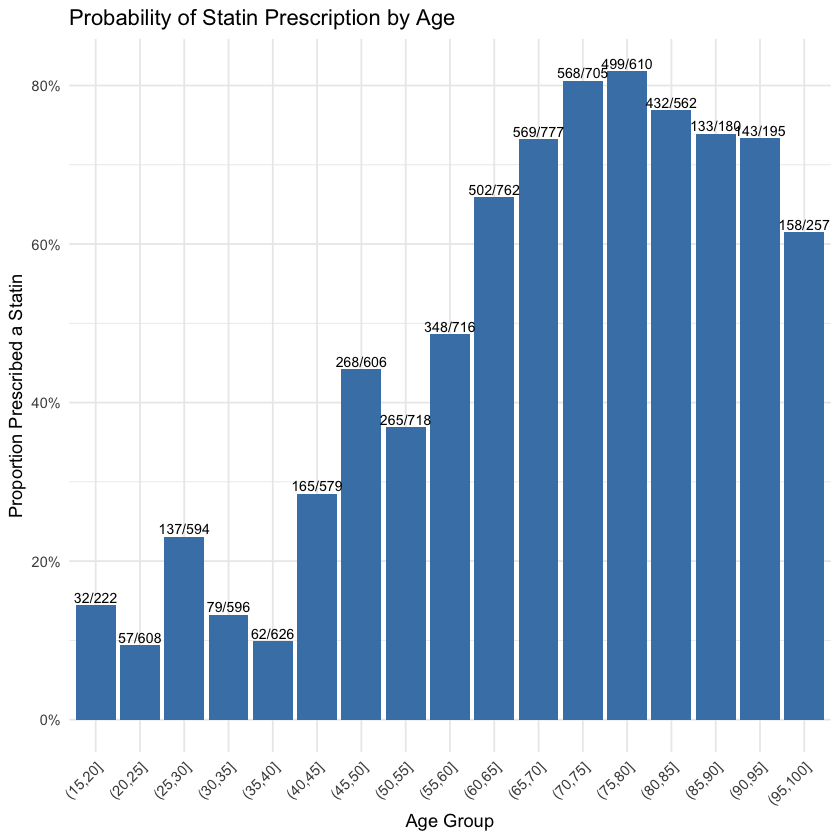

In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  ANSWER 1                                                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# QUESTION: 1 (paste question here)
# 

# CODE:



INTERPRETATION:


In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  ANSWER 2                                                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# QUESTION: (paste question here)
#

# CODE:



INTERPRETATION:


In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  ANSWER 3                                                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# QUESTION: (paste question here)
#

# CODE:



INTERPRETATION:


In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  ANSWER 4                                                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# QUESTION: (paste question here)
#

# CODE:



INTERPRETATION:


In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  ANSWER 5                                                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# QUESTION: (paste question here)
#

# CODE:



INTERPRETATION:


In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  ANSWER 6                                                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# QUESTION: (paste question here)
#

# CODE:



INTERPRETATION:


In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  ANSWER 7                                                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# QUESTION: (paste question here)
#

# CODE:



INTERPRETATION:


In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  ANSWER 8                                                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# QUESTION: (paste question here)
#

# CODE:



INTERPRETATION:


In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  ANSWER 9                                                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# QUESTION: (paste question here)
#

# CODE:



INTERPRETATION:


In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  ANSWER 10                                                                 ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# QUESTION: (paste question here)
#

# CODE:



INTERPRETATION:
